In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# Utility Functions
def slerp(v0, v1, t, DOT_THRESHOLD=0.9995):
    """
    Spherical linear interpolation between two vectors.
    Source: Andrej Karpathy's gist: https://gist.github.com/karpathy/00103b0037c5aaea32fe1da1af553355
    Args:
        v0 (torch.Tensor): the first vector
        v1 (torch.Tensor): the second vector
        t (torch.Tensor): scalar from 0 to 1 parameterizing the interpolation
    """
    v0 = v0.detach().cpu().numpy()
    v1 = v1.detach().cpu().numpy()

    dot = np.sum(v0 * v1 / (np.linalg.norm(v0) * np.linalg.norm(v1)))
    if np.abs(dot) > DOT_THRESHOLD:
        v2 = (1 - t) * v0 + t * v1  # simple linear interpolation
    else:
        theta_0 = np.arccos(dot)  # angle between latent vectors
        sin_theta_0 = np.sin(theta_0)
        theta_t = theta_0 * t
        sin_theta_t = np.sin(theta_t)
        s0 = np.sin(theta_0 - theta_t) / sin_theta_0
        s1 = sin_theta_t / sin_theta_0
        v2 = s0 * v0 + s1 * v1
    return v2

def from_numpy(*args, **kwargs):
    return torch.from_numpy(*args, **kwargs).float().to(device)


def get_numpy(tensor):
    return tensor.to("cpu").detach().numpy()


# Plotting
def visualize_mb_data(dataset, title="Muller Brown Training Data"):
    mb_dataloader = torch.utils.data.DataLoader(dataset, batch_size=4096, shuffle=True)

    num_points = 100
    x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
    y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

    x, y = torch.meshgrid(x_values, y_values, indexing = "xy")
    z = calculator.U_split(x, y).cpu()

    fig, ax = plt.subplots()
    colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
    ax.set(xlabel="x-axis", ylabel="y-axis", title=title)
    plt.colorbar(colorbar)

    # also plot batch from dataloader
    for i, batch in tqdm(enumerate(mb_dataloader)):
        ax.scatter(batch[:, 0], batch[:, 1], color='red', s=0.1)
        
    ax.set_xlim([calculator.Lx, calculator.Hx])
    ax.set_ylim([calculator.Ly, calculator.Hy])

    plt.show()
    plt.close()


def plot_losses(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="train loss")
    plt.plot(x_test, test_losses, label="test loss")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("NLL")

def plot_samples(samples: np.ndarray, title: str = "Muller Brown Samples") -> None:
    # plot a single plot with samples
    fig, ax = plt.subplots()
    num_points = 100
    x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
    y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

    x, y = torch.meshgrid(x_values, y_values, indexing = "xy")
    z = calculator.U_split(x, y).cpu()
    
        
    colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
    plt.colorbar(colorbar)
    ax.scatter(samples[:, 0], samples[:, 1], s = 0.3, color='red')

    ax.set_xlim([calculator.Lx, calculator.Hx])
    ax.set_ylim([calculator.Ly, calculator.Hy])
    plt.title(title)
    plt.show()
    plt.close()

def save_multi_scatter_2d(data: np.ndarray, steps: np.ndarray, title: str) -> None:
    fig, axs = plt.subplots(3, 3, figsize=(16, 13))
    num_points = 100
    x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
    y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

    x, y = torch.meshgrid(x_values, y_values, indexing="xy")
    z = calculator.U_split(x, y).cpu()
    for i in range(3):
        for j in range(3):
        
            colorbar = axs[i, j].imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
            plt.colorbar(colorbar)
            axs[i, j].scatter(data[i * 3 + j, :, 0], data[i * 3 + j, :, 1], s = 0.3, color='red')
            # plot path endpoints with green x
            axs[i, j].scatter(data[i * 3 + j, 0, 0], data[i * 3 + j, 0, 1], s = 100, color='orange', marker='x')
            axs[i, j].scatter(data[i * 3 + j, -1, 0], data[i * 3 + j, -1, 1], s = 100, color='orange', marker='x')

            axs[i, j].set_xlim([calculator.Lx, calculator.Hx])
            axs[i, j].set_ylim([calculator.Ly, calculator.Hy])
            axs[i, j].set_title(f"{steps[i * 3 + j]}")
    fig.suptitle(title)


def plot_results(train_losses, test_losses, samples):

    print(f"Final Test Loss: {test_losses[-1]:.4f}")

    plot_losses(
        train_losses,
        test_losses,
        f"Loss Plot",
    )

    plot_samples(samples)

    # save_multi_scatter_2d(samples, steps)


def linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps, total_steps, lr_min=0.0, lr_max=1.0):
    """
    Linear warmup with cosine decay 
    """
    def lr_lambda(current_step: int):
        if current_step < warmup_steps:
            # Linear warmup
            warmup_factor = current_step / float(max(1, warmup_steps))
            return lr_min + warmup_factor * (lr_max - lr_min)
        else:
            # Cosine decay
            progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return lr_min + 0.5 * (lr_max - lr_min) * (1 + torch.cos(torch.tensor(torch.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [3]:
from mb_dataset import MBDataset
from mb_calculator import MullerBrownPotential

calculator = MullerBrownPotential(device = "cpu")

train_dataset = MBDataset(preload_sim_dir="data/temp=700_timestep=5.0_friction=0.001/train_large")
test_dataset = MBDataset(preload_sim_dir="data/temp=700_timestep=5.0_friction=0.001/val_large")

Loading simulations from directory: data/temp=700_timestep=5.0_friction=0.001/train_large


100%|██████████| 800/800 [02:14<00:00,  5.93it/s]


Loading simulations from directory: data/temp=700_timestep=5.0_friction=0.001/val_large


100%|██████████| 200/200 [00:30<00:00,  6.52it/s]


196it [00:10, 19.53it/s]


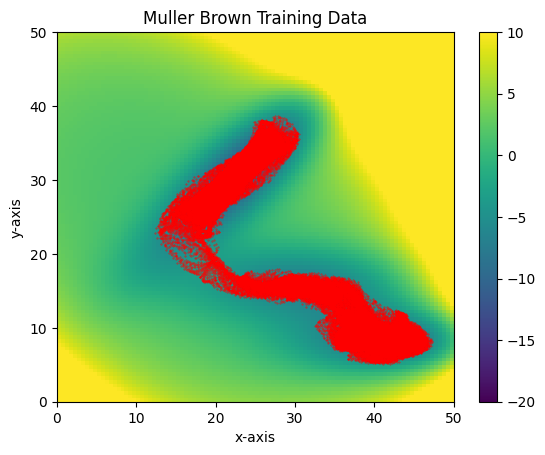

In [4]:
visualize_mb_data(train_dataset)

In [39]:
from mb_actions import SimpleAction, S2Action
from simpleMB import SimpleMB
import random

class DiffusionMLP(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_steps, device):
        super(DiffusionMLP, self).__init__()
        self.device = device
        self.in_dim = in_dim
        self.num_steps = num_steps
        self.ts = torch.linspace(1e-4, 1 - 1e-4, self.num_steps + 1).unsqueeze(-1).to(self.device)
        self.PI = torch.tensor([np.pi]).to(device)

        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) 
        self.fc3 = nn.Linear(hidden_dim, hidden_dim) 
        self.fc4 = nn.Linear(hidden_dim, hidden_dim) 
        self.fc5 = nn.Linear(hidden_dim, out_dim)  
        # add dropout layer
        # self.dropout = nn.Dropout(0.1)


    def forward(self, x, t):
        assert torch.logical_and(t <= 1, t >= 0).all(), "t must be between 0 and 1"
        if len(t.shape) <=1:
            t = torch.tensor(t).repeat(x.shape[0], 1).to(self.device)
        x = torch.cat([x, t], dim = 1)
        x = F.relu(self.fc1(x))
        # x = self.dropout(x)
        x = F.relu(self.fc2(x))
        # x = self.dropout(x)
        x = F.relu(self.fc3(x))
        # x = self.dropout(x)
        x = F.relu(self.fc4(x))
        # x = self.dropout(x)
        x = self.fc5(x)       
        return x

    def force_func(self, x, t):
        assert torch.logical_and(t <= 1, t >= 0).all(), "t must be between 0 and 1"
        noise_pred = self.forward(x, t)
        force = - noise_pred # TODO: add scaling factor
        return force
    
    def laplacian_func(self, x, t):
        assert torch.logical_and(t <= 1, t >= 0).all(), "t must be between 0 and 1"
        hessian_fn = torch.func.jacrev(self.force_func, argnums = 0)
        hessian = hessian_fn(x, t) # shape of [P x 2 x P x 2]
        indices = torch.arange(x.shape[0])
        laplace = torch.vmap(torch.diag)(hessian[indices, :, indices, :])
        return laplace
    
    def forward_diffusion(self, x, t, noise):
        assert torch.logical_and(t <= 1, t >= 0).all(), "t must be between 0 and 1"
        #compute noise strength
        alpha = torch.cos(self.PI / 2 * t)
        sigma = torch.sin(self.PI / 2 * t)
        #add random noise
        noised_x = alpha * x + sigma * noise
        return noised_x

    def ddpm_update(self, x, eps_hat, t, tm1, temperature):
        assert t <= 1 and t >= 0, "t must be between 0 and 1"
        assert tm1 <= 1 and tm1 >= 0, "tm1 must be between 0 and 1"
        t = t.repeat(x.shape[0]).unsqueeze(-1)
        tm1 = tm1.repeat(x.shape[0]).unsqueeze(-1)

        sigma_t = torch.sin(self.PI / 2 * t)
        sigma_tm1 = torch.sin(self.PI / 2 * tm1)
        alpha_t = torch.cos(self.PI / 2 * t)
        alpha_tm1 = torch.cos(self.PI / 2 * tm1)
        zeta_t = sigma_tm1 / sigma_t * torch.sqrt(1 - (alpha_t **2) / (alpha_tm1 **2))
        x_tm1 = alpha_tm1 * (x - sigma_t * eps_hat) / alpha_t + \
                eps_hat * torch.sqrt(torch.clip(sigma_tm1**2 - zeta_t**2, 0)) + \
                zeta_t * torch.randn_like(x).to(self.device)*temperature

        return x_tm1
    
    def sample(self, num_samples, temperature = 1.0):
        """Top level sampling function. Samples from the model starting from pure noise (t = T)."""
        with torch.no_grad():
            x = torch.randn((num_samples, self.in_dim - 1)).to(self.device)
            return self.sample_from_t(x, self.num_steps, temperature)

    def sample_from_t(self, x_t, latent_time, temperature = 1.0):
        """Runs reverse diffusion on x_t starting from latent_time (between 0 and self.num_steps) and returns the final sample."""
        assert latent_time <= self.num_steps and latent_time >= 0, "Time must be between 0 and num_steps"
        assert round(latent_time) == latent_time, "Time must be an integer between 0 and num_steps"
        with torch.no_grad():
            
            #begin reverse diffusion process starting at t
            for i in range(latent_time, 1, -1):
                t = self.ts[i]
                tm1 = self.ts[i - 1]
                eps_hat = self.forward(x_t, t)
                x_t = self.ddpm_update(x_t, eps_hat, t, tm1, temperature)
            return x_t
        
    def reconstruct(self, x, latent_time, temperature = 1.0):
        """Forward diffusion of samples x to t = t and then sample from t to reconstruct x."""
        if isinstance(latent_time, torch.Tensor):
            latent_time = latent_time.item()
        assert latent_time <= self.num_steps and latent_time >= 0, "Latent time must be between 0 and num_steps"
        assert round(latent_time) == latent_time, "Latent time must be an integer between 0 and num_steps"
        t = self.ts[latent_time]
        with torch.no_grad():
            noised_x = self.forward_diffusion(x, t, torch.randn_like(x).to(self.device))
            return self.sample_from_t(noised_x, latent_time, temperature)
    
    def interpolation(self, x1, x2, path_length, latent_time, interpolation_fn = torch.lerp, temperature = 1.0):
        """"
        Encode the two points into latent space, linearly or spherically interpolate, and decode.
        Note: Expects x1 and x2 to be normalized.
        """
        if isinstance(latent_time, torch.Tensor):
            latent_time = latent_time.item()
        assert latent_time <= self.num_steps and latent_time >= 0, "Latent time must be between 0 and num_steps"
        
        assert round(latent_time) == latent_time, "Latent time must be an integer between 0 and num_steps"
        original_x1 = x1.clone()
        original_x2 = x2.clone()

        t = self.ts[latent_time]

        with torch.no_grad():
            noise = torch.randn_like(x1).to(self.device)
            noised_x1 = self.forward_diffusion(x1, t, noise)
            noised_x2 = self.forward_diffusion(x2, t, noise)

        # linear interpolation of noised_x1 and noised_x2
        noised_xs = torch.stack([interpolation_fn(noised_x1.cpu(), noised_x2.cpu(), alpha) for alpha in torch.linspace(0, 1, path_length)])
        noised_xs = noised_xs.reshape(-1, 2).to(self.device)
    
        # decode
        xs = self.sample_from_t(noised_xs, latent_time, temperature)

        xs = xs.reshape(path_length, x1.shape[0], 2)
        xs = xs.clone().detach()

        # reset the endpoints
        xs[0], xs[-1] = original_x1, original_x2
        
        return xs
        
    def om_interpolation(self, x1, x2, path_length, latent_time, action_cls = SimpleAction, om_steps = 100, temperature = 1.0):
        """"
        Encode the two points into latent space, linearly interpolate, and decode
        Note: Expects x1 and x2 to be normalized.
        """
        if isinstance(latent_time, torch.Tensor):
            latent_time = latent_time.item()
        assert latent_time <= self.num_steps and latent_time >= 0, "Latent time must be between 0 and num_steps"
        assert round(latent_time) == latent_time, "Latent time must be an integer between 0 and num_steps"

        original_x1 = x1.clone()
        original_x2 = x2.clone()
        t = self.ts[latent_time]
        with torch.no_grad():
            noise = torch.randn_like(x1).to(self.device)
            noised_x1 = self.forward_diffusion(x1, t, noise)
            noised_x2 = self.forward_diffusion(x2, t, noise)

        # linear interpolation of noised_x1 and noised_x2
        noised_xs = torch.stack([torch.lerp(noised_x1.cpu(), noised_x2.cpu(), alpha) for alpha in torch.linspace(0, 1, path_length)])
        noised_xs = noised_xs.reshape(-1, 2).to(self.device)
        optimizer = torch.optim.Adam([noised_xs], lr = 0.01)
        pbar = tqdm(range(om_steps))
        paths = []

        force_func = lambda x: self.force_func(x, t)
        laplace_func = lambda x: self.laplacian_func(x, t)
        action_func = action_cls(force_func = force_func, laplace_func=laplace_func, dt = 0.1, gamma = 0.1, D = 1)
        # Optimization of path using OM action
        for i in pbar:
        
            noised_xs.requires_grad = True
            action = action_func(noised_xs)

            optimizer.zero_grad()
            grads, = torch.autograd.grad(action, noised_xs)
            
            with torch.no_grad():
                grads[0,:], grads[-1,:] = torch.zeros(2).to(self.device), torch.zeros(2).to(self.device)
                noised_xs.grad = grads
                optimizer.step()

            pbar.set_description(f"OM Action: {action.item()}")
            if i % 10 == 0:
                paths.append(noised_xs.reshape(path_length, x1.shape[0], 2).detach().cpu().numpy())

        # decode along optimized path
        with torch.no_grad():
            xs = self.sample_from_t(noised_xs, latent_time, temperature)
            xs = xs.reshape(path_length, x1.shape[0], 2)
            xs = xs.clone().detach()

            # reset the endpoints
            xs[0], xs[-1] = original_x1, original_x2

            return xs, paths
        


In [40]:
def train_mb_diffusion(train_dataset, test_dataset, model, n_epochs, device):
    """

    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch
    - a numpy array of size (9, 2000, 2) of samples drawn from your model.
      Draw 2000 samples for each of 9 different number of diffusion sampling steps
      of evenly logarithmically spaced integers 1 to 512
      hint: np.power(2, np.linspace(0, 9, 9)).astype(int)
    """

    """ YOUR CODE HERE """
    device = torch.device(torch.cuda.current_device())
    batch_size = 4096
    PI = torch.tensor([np.pi]).to(device)
    optimizer = optim.Adam(model.parameters(), lr = 1e-3)
    scheduler = linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps = 100, \
                                                        total_steps = n_epochs * int(len(train_dataset) / batch_size), \
                                                        lr_min=0.0, lr_max=1.0)

    #normalize training data
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False)
    
    mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
    std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
    # train_data = (train_data - train_mean) / train_std
    # test_data = (test_data - train_mean) / train_std

    train_losses = []
    test_losses = []
    for _ in tqdm(range(n_epochs)):
        model.train()
        # print(f"Epoch {e}")
        for x in train_dataloader:
            optimizer.zero_grad()
            x = x.to(device)
            x = (x - mean) / std
            #sample diffusion timestep (uniform between 0 and 1)
            t = torch.rand((x.shape[0], 1)).to(device)
            # sample noise and diffuse
            noise = torch.randn_like(x)
            noised_x = model.forward_diffusion(x, t, noise)
            #forward pass
            pred_noise = model(noised_x, t).to(torch.float32)
            #compute loss and optimize
            loss = F.mse_loss(pred_noise, noise)
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_losses.append(loss.unsqueeze(-1))

        model.eval()
        tls = []
        with torch.no_grad():
            for x in test_dataloader:
                #sample diffusion timestep
                x = x.to(device)
                x = (x - mean) / std
                t = torch.rand((x.shape[0], 1)).to(device)

                # sample noise and diffuse
                noise = torch.randn_like(x)
                noised_x = model.forward_diffusion(x, t, noise)
                
                #forward pass
                pred_noise = model(noised_x, t).to(torch.float32)
                #compute loss and optimize
                loss = F.mse_loss(pred_noise, noise)
                tls.append(loss.unsqueeze(-1))
            test_loss = torch.cat(tls).sum(0) / len(tls)
            test_losses.append(test_loss.unsqueeze(-1))
            # print("Test loss: ", test_losses[-1].item())
            
    return get_numpy(torch.cat(train_losses)), get_numpy(torch.cat(test_losses))


In [41]:
# Train the model
device = torch.device(torch.cuda.current_device())
model = DiffusionMLP(3, 256, 2, 256, device).to(device).to(torch.float32)
n_epochs = 10
train_losses, test_losses = train_mb_diffusion(train_dataset, test_dataset, model, n_epochs, device)

/tmp/ipykernel_398302/1374584742.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_398302/1374584742.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [01:35<00:00,  9.57s/it]


/tmp/ipykernel_398302/3481198039.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).repeat(x.shape[0], 1).to(self.device)
/tmp/ipykernel_398302/3034786098.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_398302/3034786098.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std = torch.tensor(train_dataset.std).to(device).to(torch.float32)


Final Test Loss: 0.2412


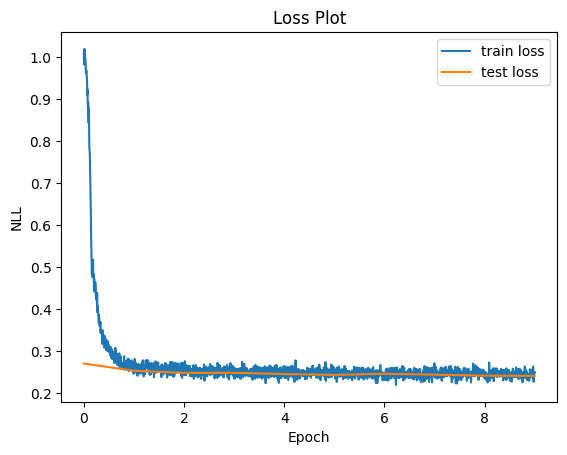

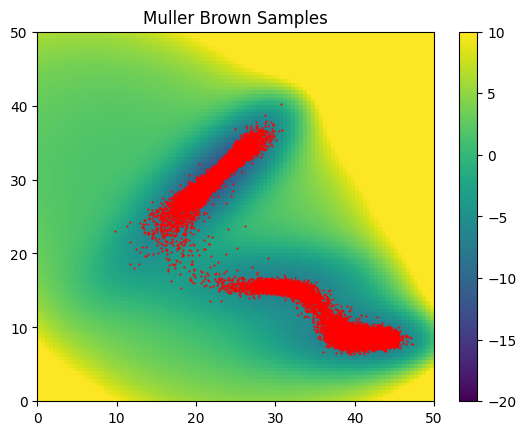

In [42]:
# Unconditional samples from the model
all_samples = model.sample(100000, temperature = 1)
mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
all_samples = all_samples*std + mean

plot_results(train_losses, test_losses, get_numpy(all_samples))
# visualize_mb_data(train_dataset)

  0%|          | 0/40 [00:00<?, ?it/s]/tmp/ipykernel_398302/3481198039.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).repeat(x.shape[0], 1).to(self.device)
100%|██████████| 40/40 [00:02<00:00, 14.95it/s]
49it [00:03, 14.44it/s]


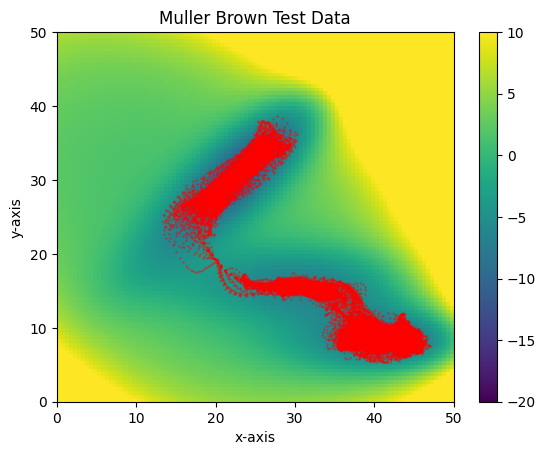

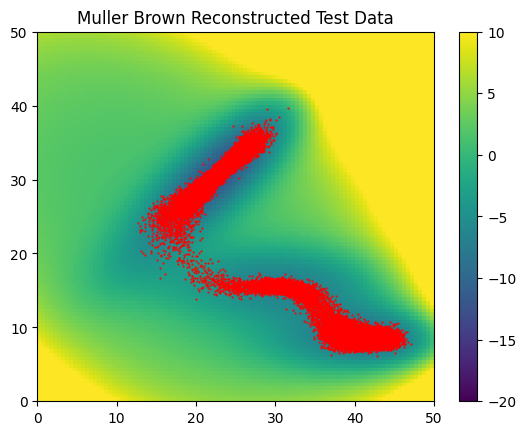

In [54]:
# Reconstruction of test data (first batch of dataloader)
model.eval()
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = 5000, shuffle = False)
reconstructed_xs = []
for x in tqdm(test_dataloader):
    x = x.to(device)
    x = (x - mean) / std
    reconstructed_x = model.reconstruct(x, 25, temperature = 1.0)
    reconstructed_x = reconstructed_x * std + mean
    reconstructed_xs.append(reconstructed_x)

reconstructed_xs = torch.cat(reconstructed_xs)

visualize_mb_data(test_dataset, title = "Muller Brown Test Data")
plot_samples(get_numpy(reconstructed_xs), title = "Muller Brown Reconstructed Test Data")

In [55]:
# Define common args for interpolation experiments
latent_times = torch.linspace(0, 256, 9).to(torch.long).to(device)

# start and end points for interpolation - end point is different from basin to ensure we're not just i.i.d sampling
x1 = calculator.initial_point.to(device).unsqueeze(0) 
# x2 = calculator.final_point.to(device).unsqueeze(0)
x2 = torch.Tensor([[31, 15]]).to(device)

# Normalize the points
x1 = (x1 - mean) / std
x2 = (x2 - mean) / std


/tmp/ipykernel_398302/3481198039.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).repeat(x.shape[0], 1).to(self.device)


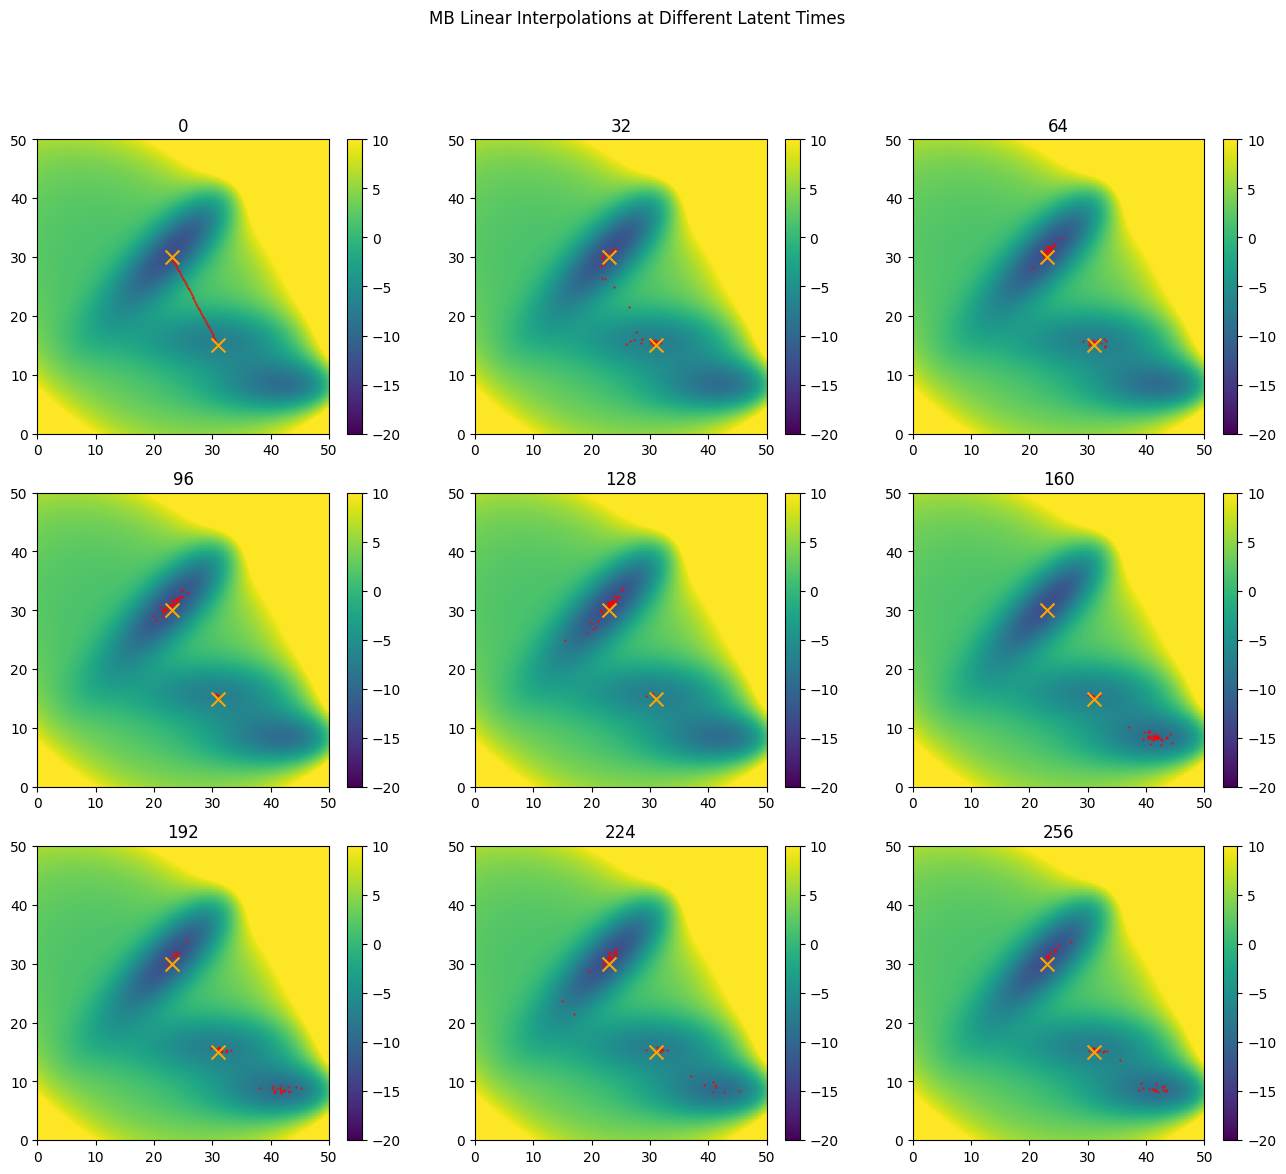

In [56]:
# linear interpolation in diffusion space
samples = torch.stack([model.interpolation(x1, x2, path_length=50, latent_time=time) for time in latent_times])
samples = samples*std + mean
save_multi_scatter_2d(get_numpy(samples.squeeze()), latent_times, title = "MB Linear Interpolations at Different Latent Times")

/tmp/ipykernel_398302/1019396027.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sin_theta_t = np.sin(theta_t)
/tmp/ipykernel_398302/1019396027.py:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  s0 = np.sin(theta_0 - theta_t) / sin_theta_0
/tmp/ipykernel_398302/1019396027.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  v2 = s0 * v0 + s1 * v1
/tmp/ipykernel_398302/3481198039.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).repeat(x.shape[0], 1).to(self.device)
/tmp/ipykernel_398302/1019396027.py:24: DeprecationWarning: __array_wrap

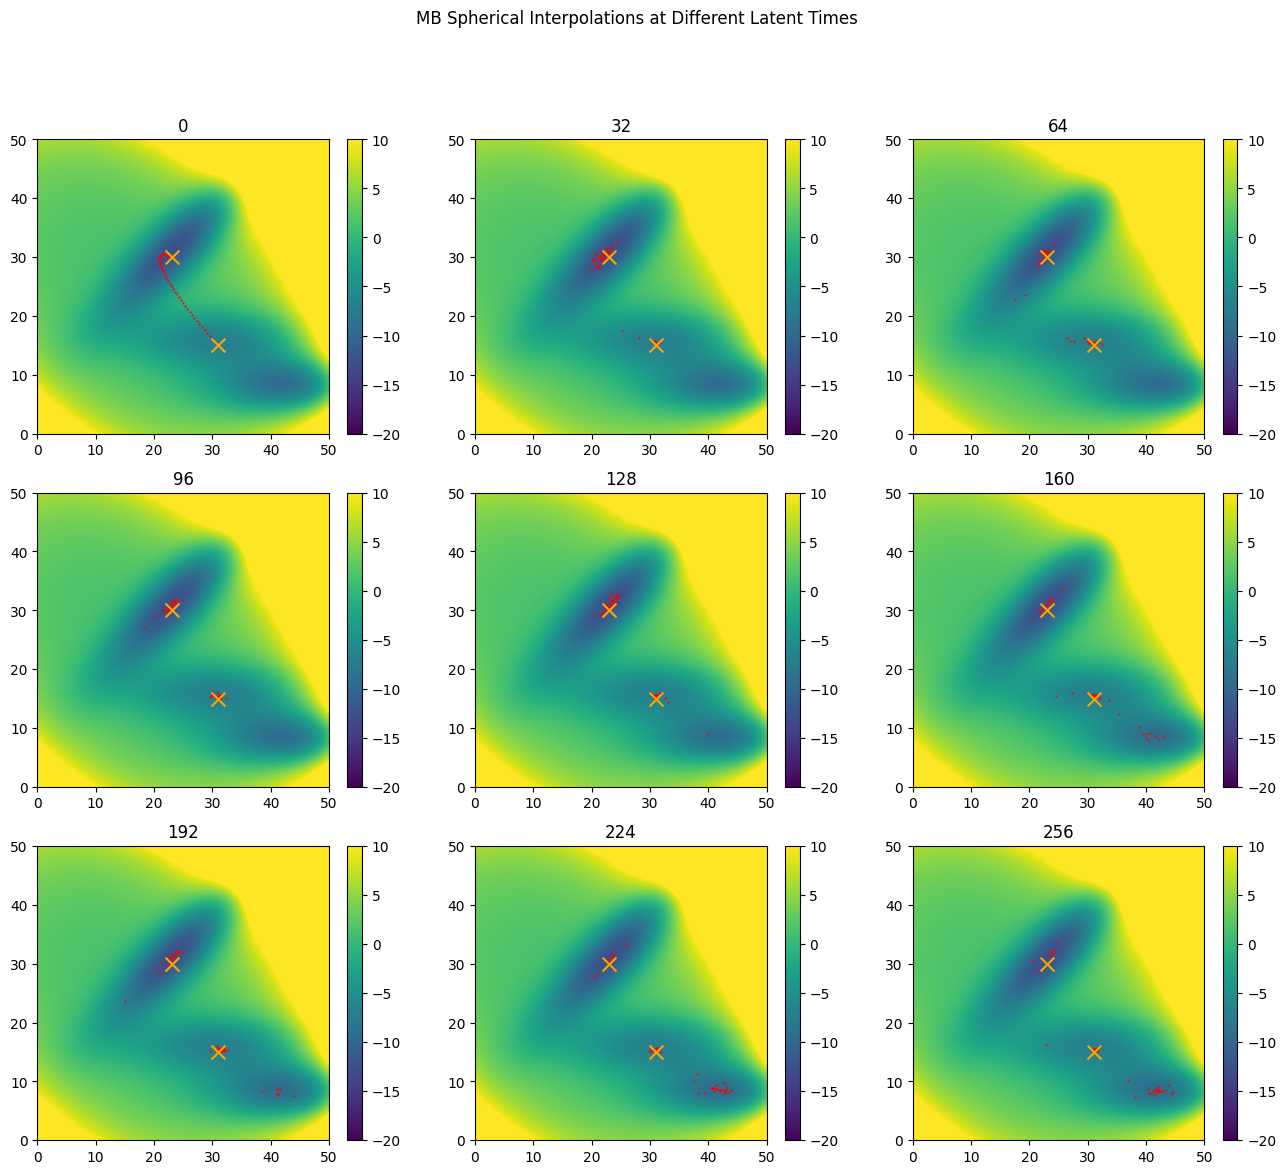

In [57]:
# spherical interpolation in diffusion space
samples = torch.stack([model.interpolation(x1, x2, path_length=50, latent_time=time, interpolation_fn=slerp) for time in latent_times])
samples = samples*std + mean
save_multi_scatter_2d(get_numpy(samples.squeeze()), latent_times, title = "MB Spherical Interpolations at Different Latent Times")

  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_398302/3481198039.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).repeat(x.shape[0], 1).to(self.device)
OM Action: 41.324798583984375:   0%|          | 0/1000 [00:00<?, ?it/s]

OM Action: 0.898425817489624: 100%|██████████| 1000/1000 [00:02<00:00, 449.32it/s]


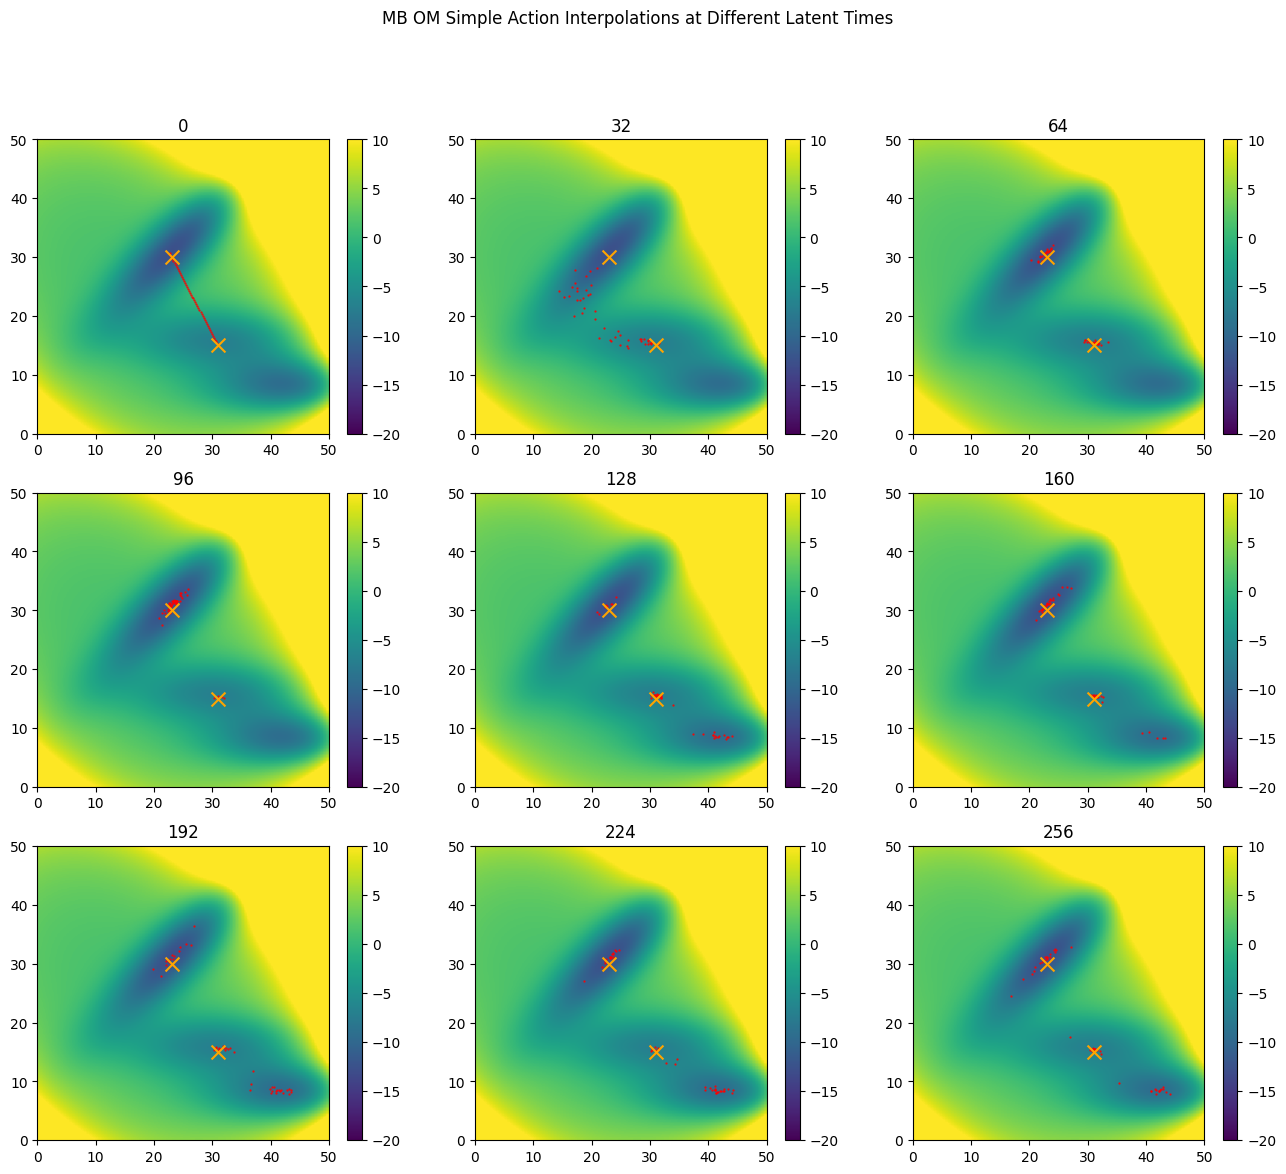

In [58]:
# om interpolation in diffusion space - SimpleAction
out = [model.om_interpolation(x1, x2, path_length=50, latent_time=time, om_steps = 1000) for time in latent_times] 
samples, paths = zip(*out) # TODO: plot evolution of paths during optimization
samples = torch.stack(samples)
samples = samples*std + mean

save_multi_scatter_2d(get_numpy(samples.squeeze()), latent_times, title = "MB OM Simple Action Interpolations at Different Latent Times")

  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_398302/3481198039.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).repeat(x.shape[0], 1).to(self.device)
OM Action: -3.8315327167510986: 100%|██████████| 1000/1000 [00:04<00:00, 236.10it/s] 


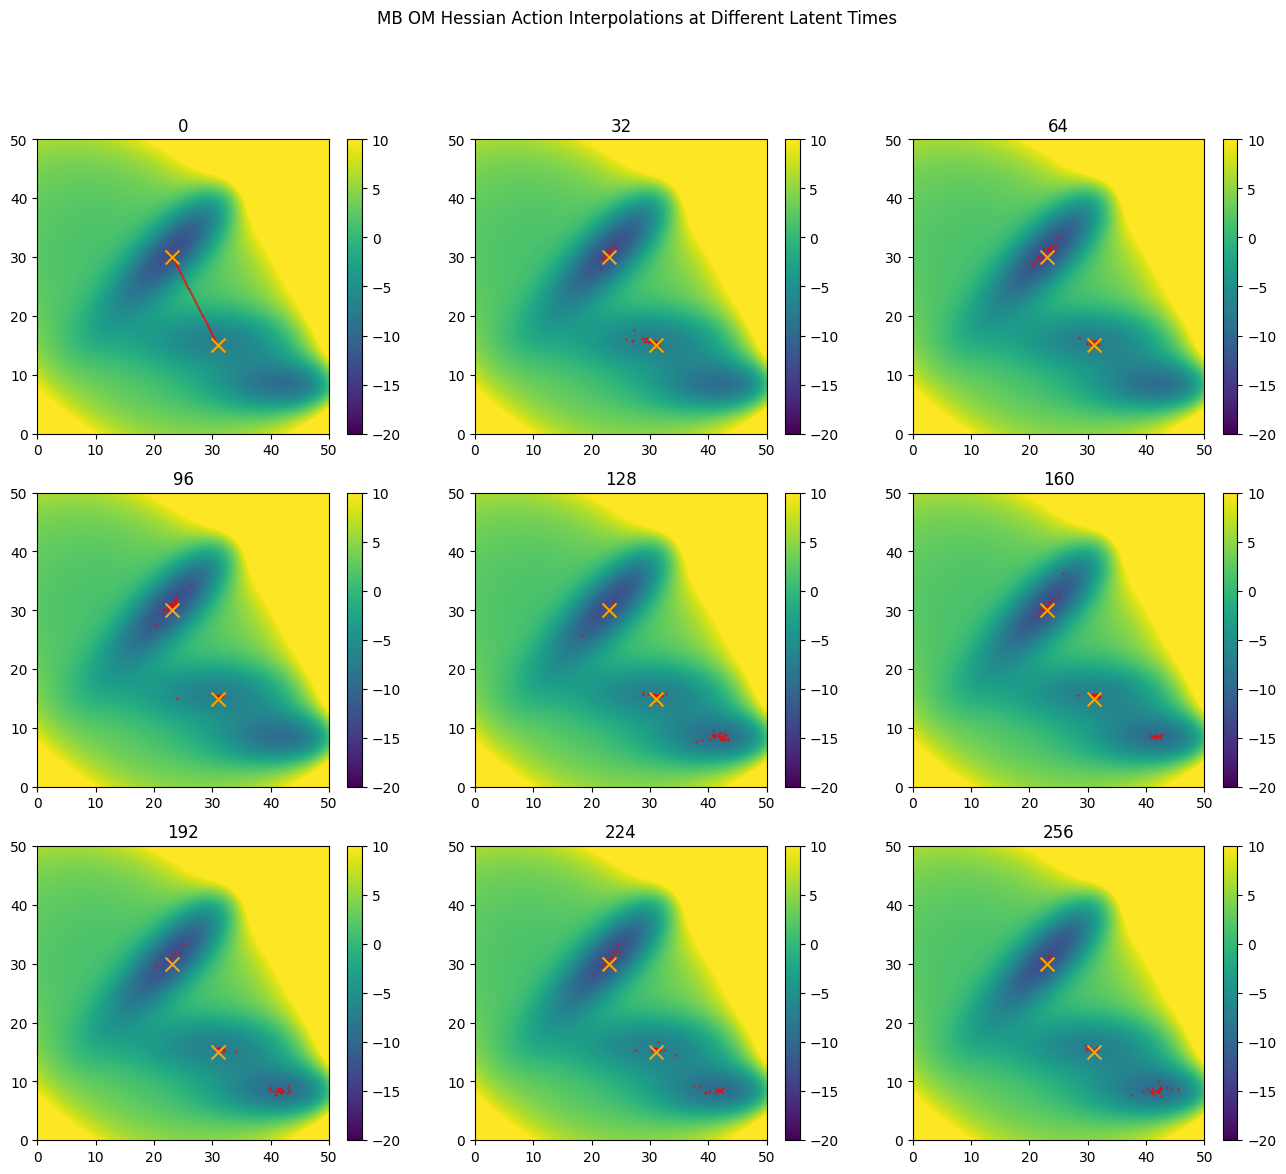

In [59]:
# om interpolation in diffusion space - S2Action
out = [model.om_interpolation(x1, x2, path_length=50, action_cls = S2Action, latent_time=time, om_steps = 1000) for time in latent_times] 
samples, paths = zip(*out) # TODO: plot evolution of paths during optimization
samples = torch.stack(samples)
samples = samples*std + mean

save_multi_scatter_2d(get_numpy(samples.squeeze()), latent_times, title = "MB OM Hessian Action Interpolations at Different Latent Times")